<h1 align="center"> PANDAS </h1>

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Bài 1 - Đọc và khám phá dữ liệu

1. Đọc file train.csv vào DataFrame [df].

In [3]:
df=  pd.read_csv("train.csv")

2. Hiển thị 5 dòng đầu tiên của dataset [df.head()].

In [4]:
df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


3. Kiểm tra số lượng hàng và cột [df.shape].

In [6]:
df.shape

(891, 12)

4. Hiển thị thông tin tổng quan về kiểu dữ liệu của từng cột [df.info()].

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


5. Kiểm tra số lượng giá trị bị thiếu (NaN, null) trong từng cột.

In [8]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

### Bài 2 - Lọc và thống kê dữ liệu

1. Tính số lượng hành khách nam và nữ Sex. Vẽ biểu đồ bar chart thể hiện
số lượng hành khách theo giới tính.

In [11]:
count = df['Sex'].value_counts()
print(count)

Sex
male      577
female    314
Name: count, dtype: int64


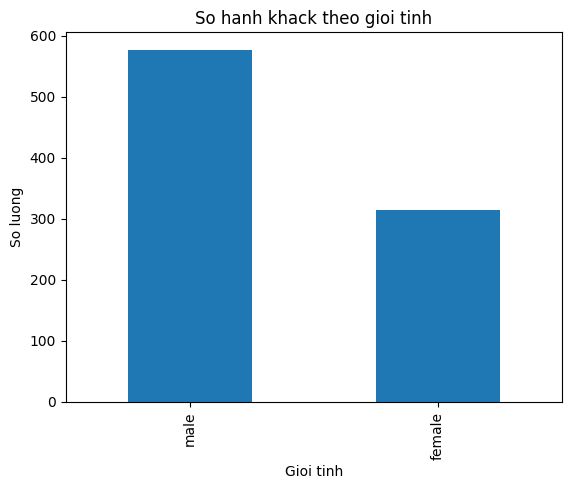

In [12]:
count.plot(kind='bar')
plt.title("So hanh khack theo gioi tinh")
plt.xlabel("Gioi tinh")
plt.ylabel("So luong")
plt.show()

2. Tính số lượng hành khách ở mỗi hạng vé Pclass. Vẽ biểu đồ pie chart thể
hiện tỷ lệ hạng vé trên tàu. Kiểm tra số lượng hành khách mua vé hạng
nhất tại cảng Southampton.

In [13]:
Pclass_count = df['Pclass'].value_counts().sort_index()
print(Pclass_count)

Pclass
1    216
2    184
3    491
Name: count, dtype: int64


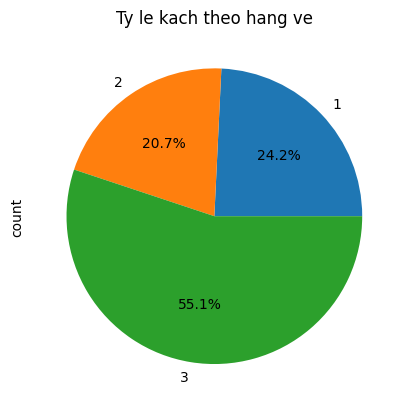

In [14]:
Pclass_count.plot(kind='pie', autopct='%1.1f%%')
plt.title("Ty le kach theo hang ve")
plt.show()

In [15]:
first_count = df[(df['Pclass'] == 1) & (df['Embarked'] == 'S')].shape[0]
print("So hanh khach hang nhat : ", first_count)

So hanh khach hang nhat :  127


3. Tính tuổi trung bình của tất cả hành khách và tuổi trung bình của những
người sống sót (Survived == 1).

In [18]:
age_all = df['Age'].mean()
age_survived = df[df['Survived'] == 1]['Age'].mean()

print("Tuoi trung binh tat ca : ", age_all)
print("Tuoi trung binh cua nhung nguoi con song : ", age_survived)

Tuoi trung binh tat ca :  29.69911764705882
Tuoi trung binh cua nhung nguoi con song :  28.343689655172415


4. Tính tỷ lệ sống sót của từng giới tính. Thống kê số lượng hành khách còn
sống mang giới tính nữ có độ tuổi lớn hơn độ tuổi trung bình của tất cả
hành khách.

In [19]:
rate = df.groupby('Sex')['Survived'].mean()
print(rate)

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


### Bài 3 - Xử lý dữ liệu thiếu và biến đổi dữ liệu

1. Kiểm tra và điền những giá trị bị thiếu trong cột Age theo yêu cầu sau:
- Với những hành khách có hạng vé 1, thay thế giá trị bị thiếu bằng
tuổi trung bình (mean) của hành khách có cùng hạng vé.
- Với những hành khách hạng vé 2 và 3, thay thế giá trị bị thiếu bằng

In [33]:
age_pclass1 = df[df['Pclass'] == 1]['Age'].mean()
df.loc[(df['Pclass'] == 1) & (df['Age'].isnull()),'Age'] = age_pclass1

In [29]:
print("Mean Age Pclass 1:", age_pclass1)
print(df.loc[(df['Pclass'] == 1) & (df['Age'].isnull()), 'Age'])

Mean Age Pclass 1: 38.233440860215055
Series([], Name: Age, dtype: float64)


In [28]:
df.loc[(df['Pclass'] == 1) & (df['Age'].isnull()), 'Age']


Series([], Name: Age, dtype: float64)

In [30]:
median_age_pclass_2_3 = df[df['Pclass'].isin([2, 3])]['Age'].median()

df.loc[
    (df['Pclass'].isin([2, 3])) & (df['Age'].isnull()),
    'Age'
] = median_age_pclass_2_3


2. Điền giá trị thiếu trong cột Embarked theo yêu cầu:
- Nếu hành khách có giá vé Fare cao hơn mức trung bình, giả định
họ có khả năng lên tàu ở cảng Cherbourg.
- Ngược lại, điền bằng cảng Southampton.

In [32]:
mean_fare = df['Fare'].mean()
print(mean_fare)

32.204207968574636


In [34]:
df.loc[
    df['Embarked'].isnull() & (df['Fare'] > mean_fare),
    'Embarked'
] = 'C'

df.loc[
    df['Embarked'].isnull() & (df['Fare'] <= mean_fare),
    'Embarked'
] = 'S'


3. Xóa cột Cabin vì có quá nhiều giá trị thiếu.

In [ ]:
df.drop(columns=['Cabin'], inplace=True)

4. Tạo cột mới FamilySize = SibSp + Parch + 1 (số thành viên trong gia
đình).

In [37]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

5. Mã hóa cột Sex thành dạng số (0 = Male, 1 = Female).

In [38]:
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})


In [39]:
df.isnull().sum()
df.head()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    int64  
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    object 
 11  FamilySize   891 non-null    int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 83.7+ KB


### Bài 4 - Trích xuất và lưu trữ dữ liệu

1. Tính giá vé trung bình Fare của mỗi hạng vé Pclass và tìm những hành
khách trả mức giá vé cao nhất của mỗi hạng vé.

In [40]:
avg_fare = df.groupby('Pclass')['Fare'].mean()
print(avg_fare)


Pclass
1    84.154687
2    20.662183
3    13.675550
Name: Fare, dtype: float64


In [41]:
max_fare = df.groupby('Pclass')['Fare'].idxmax()
highest_fare = df.loc[max_fare]

print(highest_fare[['PassengerId', 'Pclass', 'Fare', 'Name']])


     PassengerId  Pclass      Fare                        Name
258          259       1  512.3292            Ward, Miss. Anna
72            73       2   73.5000        Hood, Mr. Ambrose Jr
159          160       3   69.5500  Sage, Master. Thomas Henry


2. Tính số lượng hành khách sống sót trong mỗi nhóm tuổi Age chia thành
các nhóm: [0-18, 19-35, 36-60, >60].

In [42]:
bins = [0, 18, 35, 60, 100]
labels = ['0-18', '19-35', '36-60', '>60']

df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)

In [43]:
agegroup = df[df['Survived'] == 1]['AgeGroup'].value_counts().sort_index()
print(agegroup)


AgeGroup
0-18      70
19-35    175
36-60     92
>60        5
Name: count, dtype: int64


3. Tạo DataFrame chứa hành khách có Fare > 50 và lưu vào file
high_fare_passengers.csv.

In [44]:
high_fare_df = df[df['Fare'] > 50]

In [45]:
high_fare_df.to_csv("high_fare_passengers.csv", index=False)

4. Tạo DataFrame mới thống kê số lượng hành khách theo Pclass và
Survived vào file summary.csv.

In [46]:
summary_df = df.groupby(['Pclass', 'Survived']).size().reset_index(name='Count')
print(summary_df)

   Pclass  Survived  Count
0       1         0     80
1       1         1    136
2       2         0     97
3       2         1     87
4       3         0    372
5       3         1    119


In [47]:
summary_df.to_csv("summary.csv", index=False)